In [1]:
import bstree
import hashset
import time
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
def insert_bstree(amount) :
    time_insert = []
    test_tree = bstree.bstree()

    for i in amount :
        start_time = time.time()
        test_tree.insert(i)
        end_time = time.time()
        time_insert.append((end_time - start_time) * 10**3)

    return time_insert

def insert_hashset(amount) :
    time_insert = []
    test_hash = hashset.hashset()

    for i in amount :
        start_time = time.time()
        test_hash.insert(i)
        end_time = time.time()
        time_insert.append((end_time - start_time) * 10**3)

    return time_insert 

def main(size_ray) :
    size = size_ray
    amount_array = np.arange(1, size + 1, 1)
    text_list = []

    with open("dict", "r") as fp :
        for i, line in enumerate(fp) :
            if i in range(size) :
                text_list.append(line)
            elif i > size :
                break

    bstree_time = insert_bstree(text_list)
    hashset_time = insert_hashset(text_list)
    # hashset_time = amount_array
    
    return amount_array, bstree_time, hashset_time

In [3]:
amount_array, bstree_time, hashset_time = main(20000)

In [4]:
print(f"{bstree_time}\n{hashset_time}")

[0.0054836273193359375, 0.009775161743164062, 0.00858306884765625, 0.00667572021484375, 0.00476837158203125, 0.0035762786865234375, 0.0035762786865234375, 0.0026226043701171875, 0.0054836273193359375, 0.003337860107421875, 0.003337860107421875, 0.0057220458984375, 0.0045299530029296875, 0.003337860107421875, 0.0040531158447265625, 0.00476837158203125, 0.004291534423828125, 0.005245208740234375, 0.004291534423828125, 0.0040531158447265625, 0.005245208740234375, 0.0059604644775390625, 0.00476837158203125, 0.003814697265625, 0.003814697265625, 0.0050067901611328125, 0.0069141387939453125, 0.0030994415283203125, 0.0030994415283203125, 0.006198883056640625, 0.026464462280273438, 0.00762939453125, 0.0030994415283203125, 0.0073909759521484375, 0.0069141387939453125, 0.0054836273193359375, 0.005245208740234375, 0.017881393432617188, 0.007867813110351562, 0.009298324584960938, 0.0069141387939453125, 0.008821487426757812, 0.006198883056640625, 0.0059604644775390625, 0.00762939453125, 0.006675720

In [5]:
print(amount_array[-1])

20000


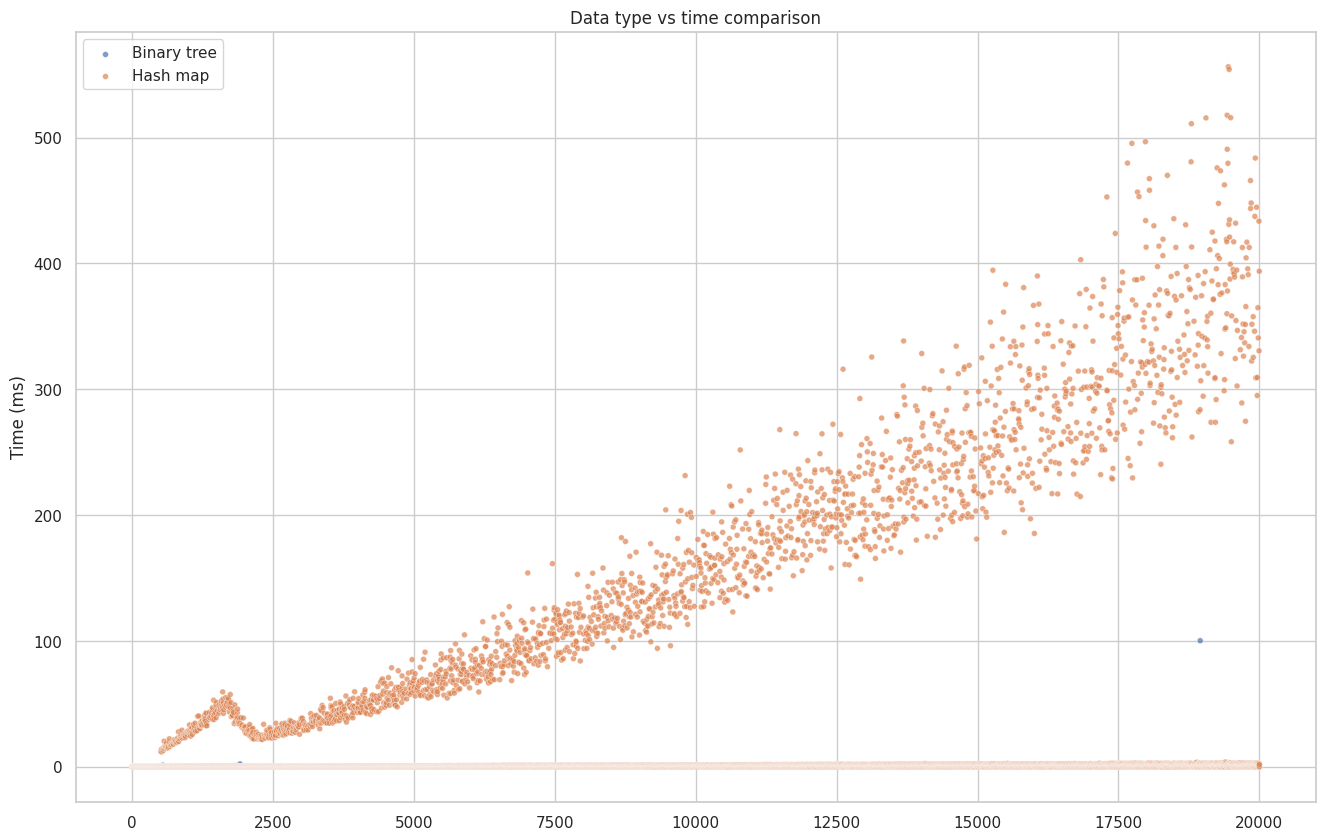

In [6]:
sns.set(style = "whitegrid")
plt.figure(figsize=(16, 10))
sns.scatterplot(x = amount_array, y = bstree_time, alpha=0.7, size=4, label = "Binary tree", legend=False)
sns.scatterplot(x = amount_array, y = hashset_time, alpha=0.7, size=4, label = "Hash map", legend=False)
plt.title("Data type vs time comparison")
plt.ylabel("Time (ms)")
plt.legend()

plt.savefig("comparison.jpg")

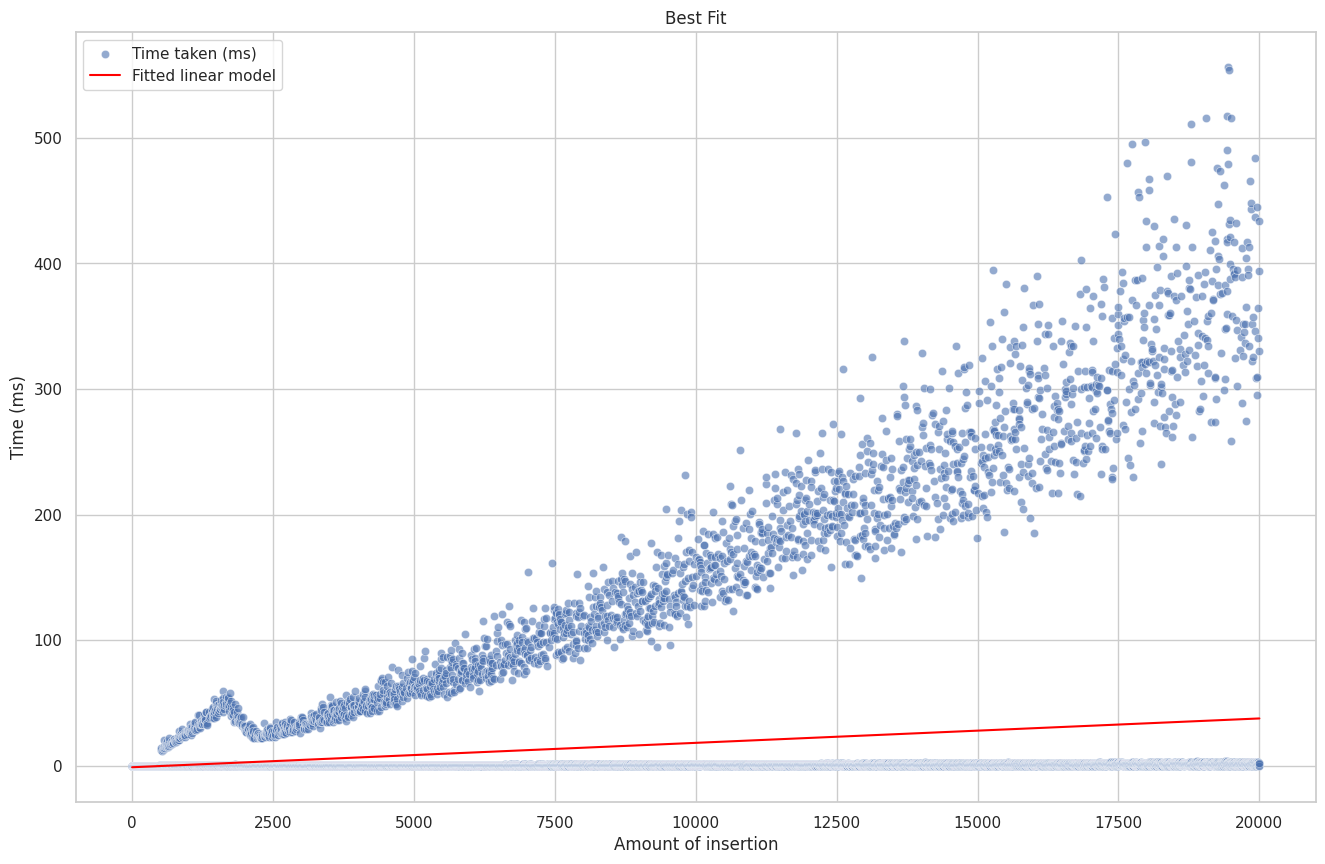

In [7]:
coefficients = np.polyfit(amount_array, hashset_time, 1)
slope, intercept = coefficients

y_fit = slope * amount_array + intercept

sns.set(style = "whitegrid")
plt.figure(figsize=(16, 10))

sns.scatterplot(x = amount_array, y = hashset_time, label='Time taken (ms)', alpha=0.6)
plt.plot(amount_array, y_fit, color='red', label='Fitted linear model')
plt.xlabel('Amount of insertion')
plt.ylabel('Time (ms)')
plt.legend()
plt.title('Best Fit')

plt.savefig("hashset.jpg")

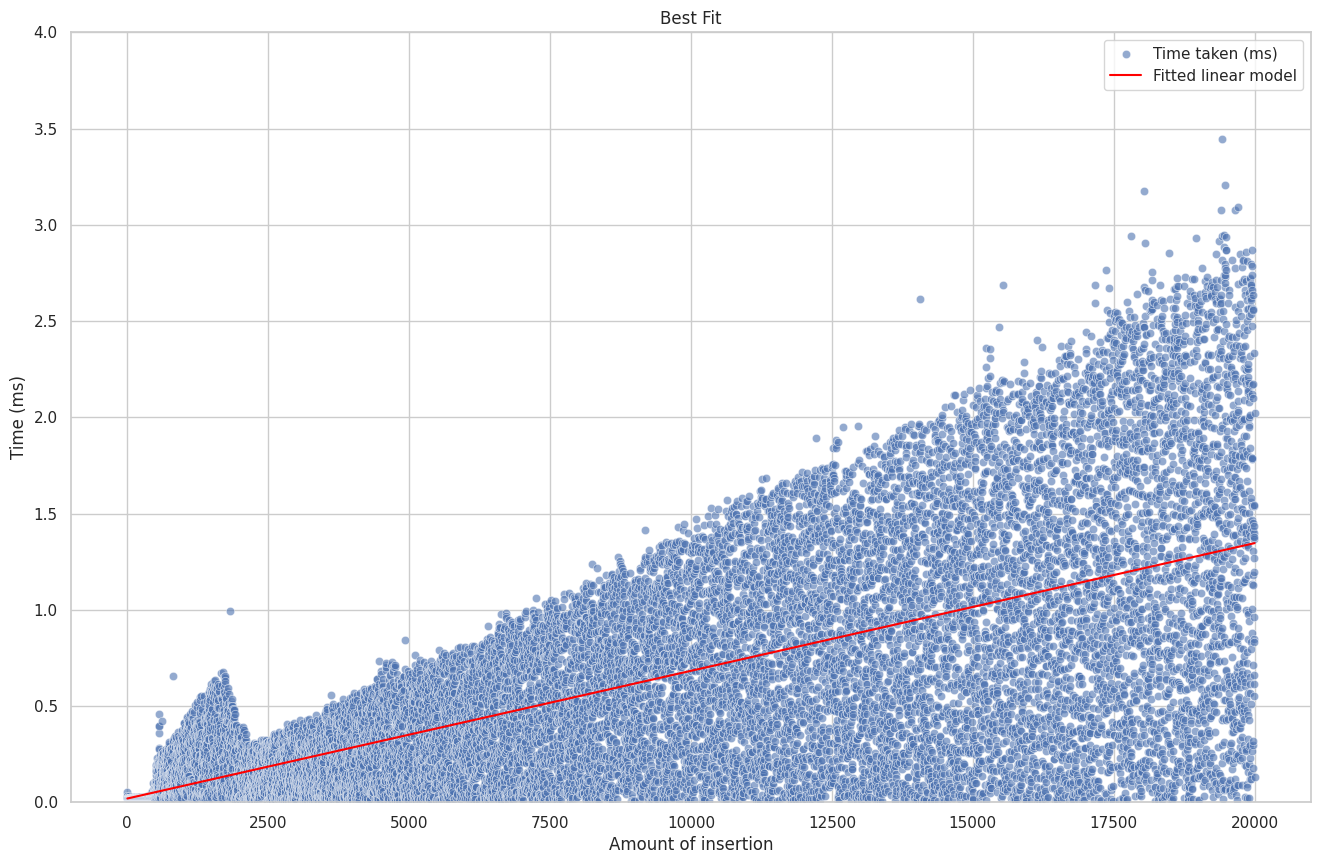

In [8]:
y_min = 0
y_max = 3.5

x = np.array(amount_array)
y = np.array(hashset_time)

filtered_x = x[(y >= y_min) & (y <= y_max)]
filtered_y = y[(y >= y_min) & (y <= y_max)]

coefficients = np.polyfit(filtered_x, filtered_y, 1)
slope, intercept = coefficients

y_fit = slope * filtered_x + intercept

sns.set(style = "whitegrid")
plt.figure(figsize=(16, 10))

sns.scatterplot(x = filtered_x, y = filtered_y, label='Time taken (ms)', alpha=0.6)
plt.plot(filtered_x, y_fit, color='red', label='Fitted linear model')
plt.xlabel('Amount of insertion')
plt.ylabel('Time (ms)')
plt.ylim(0, 4)
plt.legend()
plt.title('Best Fit')

plt.savefig("test_hashset.jpg")

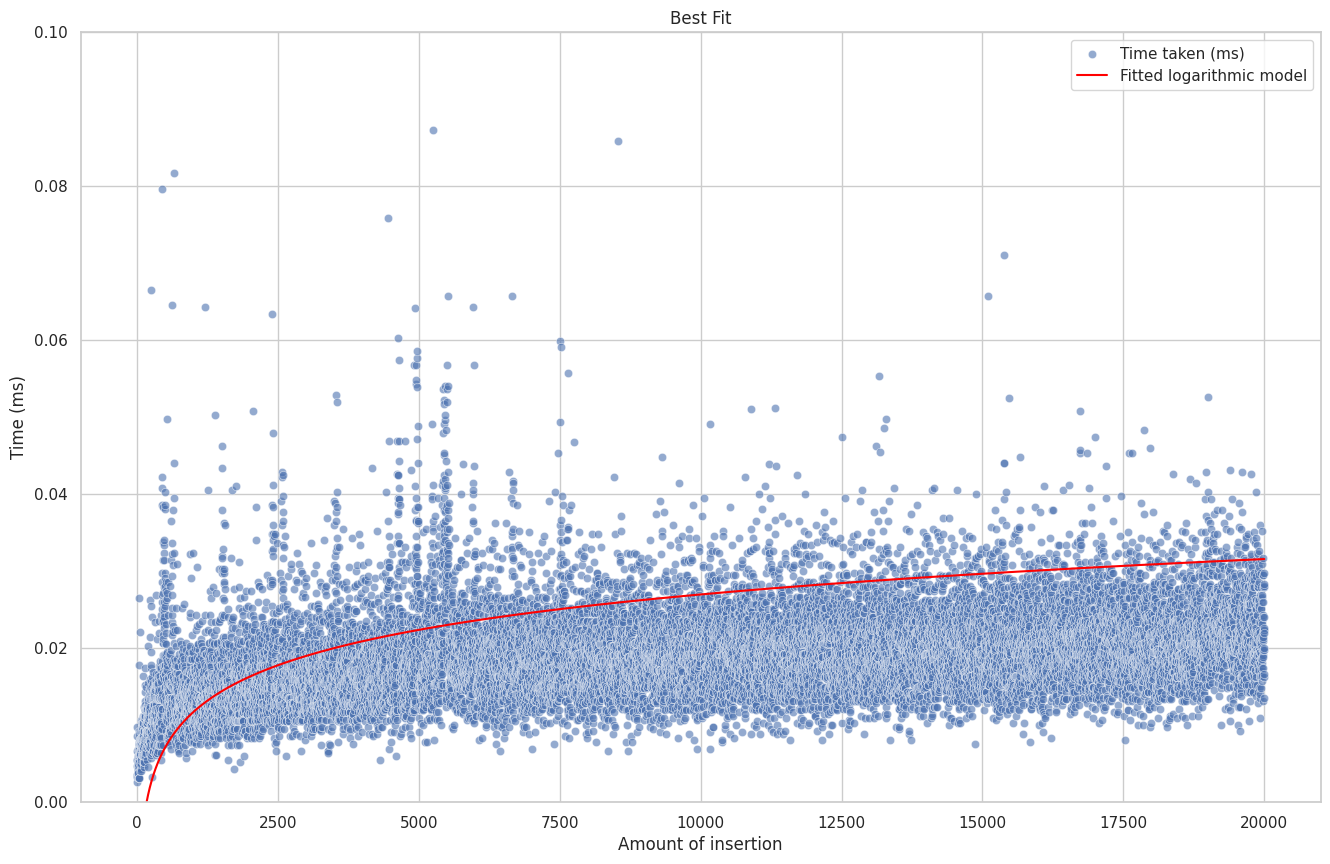

In [9]:
log_x = np.log(amount_array)
coefficients = np.polyfit(log_x, bstree_time, 1)
slope, intercept = coefficients

# Predict using the fitted model
y_fit = slope * log_x + intercept

sns.set(style = "whitegrid")
plt.figure(figsize=(16, 10))

sns.scatterplot(x = amount_array, y = bstree_time, label='Time taken (ms)', alpha=0.6)
plt.plot(amount_array, y_fit, color='red', label='Fitted logarithmic model')
plt.xlabel('Amount of insertion')
plt.ylabel('Time (ms)')
plt.ylim(0, 0.1)
plt.legend()
plt.title('Best Fit')

plt.savefig("binary.jpg")

In [13]:
np.savetxt("hashset_data.csv", hashset_time, delimiter = ",", fmt = "%.19f", header = "time")
np.savetxt("bstree_data.csv", bstree_time, delimiter = ",", fmt = "%.19f", header = "time")